### 7CS074 - Final Assessment: Ethereum Directional Forecasting

**Abstract**

This report presents a complete data mining workflow for Ethereum market analysis using the dataset `Ethereum_historical_data_coinmarketcap.csv`. The objective is to predict next-day price direction (up/down) from historical daily market variables and engineered features. The study implements a reproducible Python pipeline: data loading and validation, preprocessing, feature engineering, exploratory diagnostics, model selection, hyperparameter tuning with walk-forward validation, and multi-metric evaluation.

A key strength of this work is methodological rigor for time series: chronological train/test splitting and `TimeSeriesSplit` cross-validation reduce look-ahead bias. Models include a naïve benchmark (`DummyClassifier`), interpretable non-linear baseline (`DecisionTreeClassifier`), and stronger ensemble benchmark (`RandomForestClassifier`). Evaluation extends beyond accuracy to include balanced accuracy, precision, recall, F1, ROC-AUC, PR-AUC, Matthews correlation coefficient (MCC), Cohen’s kappa, log loss, and Brier score.

Overall, the study demonstrates that feature engineering and robust model validation provide meaningful gains over naïve prediction, while highlighting common limitations in cryptocurrency forecasting: non-stationarity, structural breaks, and high volatility. The report concludes with reproducibility guidance, critical reflection, and recommendations for future improvements such as rolling retraining, probability calibration, and cost-aware evaluation.

**Scope**
- Data collection and understanding
- Data pre-processing and exploratory analysis
- Methodology and algorithm selection
- Implementation, metrics, and visual results
- Evaluation and comparison of approaches

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from statsmodels.tsa.stattools import adfuller

from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef, cohen_kappa_score,
    log_loss, brier_score_loss, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", 100)
sns.set_style("whitegrid")

##### 1. Data Collection and Understanding

Load the Ethereum historical dataset, validate structure, parse timestamps, and perform integrity checks.

- **Data source:** [CoinMarketCap historical CSV export.](https://coinmarketcap.com/currencies/ethereum/historical-data/)
- Granular daily data for time series analysis. 
- **Ethics:** Public aggregated data; consider volatility risks in crypto.

In [2]:
# Load the dataset
csv_path = Path("Ethereum_historical_data_coinmarketcap.csv")
if not csv_path.exists():
    raise FileNotFoundError(f"Dataset not found: {csv_path.resolve()}")

raw_df = pd.read_csv(csv_path, sep=";")
print("Raw shape:", raw_df.shape)
print("Raw columns:", list(raw_df.columns))

df = raw_df.copy()
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True, errors="coerce")

invalid_ts = df["timestamp"].isna().sum()
dup_count_before = df.duplicated().sum()

df = df.dropna(subset=["timestamp"]).drop_duplicates().sort_values("timestamp").set_index("timestamp")

drop_cols = ["timeOpen", "timeClose", "timeHigh", "timeLow", "name"]
df = df.drop(columns=drop_cols, errors="ignore")

print("\nInvalid timestamps removed:", invalid_ts)
print("Duplicate rows removed:", dup_count_before)
print("Final shape:", df.shape)
print("\nMissing values per column:\n", df.isna().sum())
print("\nData types:\n", df.dtypes)

Raw shape: (3860, 13)
Raw columns: ['timeOpen', 'timeClose', 'timeHigh', 'timeLow', 'name', 'open', 'high', 'low', 'close', 'volume', 'marketCap', 'circulatingSupply', 'timestamp']

Invalid timestamps removed: 0
Duplicate rows removed: 0
Final shape: (3860, 7)

Missing values per column:
 open                 0
high                 0
low                  0
close                0
volume               0
marketCap            0
circulatingSupply    0
dtype: int64

Data types:
 open                 float64
high                 float64
low                  float64
close                float64
volume               float64
marketCap            float64
circulatingSupply    float64
dtype: object


##### 2. Data Pre-processing and Feature Construction

Create predictive features, define a leakage-safe target, and prepare baseline and feature-engineered datasets.

In [3]:
# Core features
df["lag_close_1"] = df["close"].shift(1)
df["lag_close_3"] = df["close"].shift(3)
df["lag_close_7"] = df["close"].shift(7)

# Return and volatility features
df["ret_1d"] = df["close"].pct_change(1)
df["ret_7d"] = df["close"].pct_change(7)
df["volatility_7d"] = df["ret_1d"].rolling(7).std()

# Ratio features
df["high_low_ratio"] = df["high"] / df["low"]
df["range_ratio"] = (df["high"] - df["low"]) / df["lag_close_1"]
df["open_ratio"] = df["open"] / df["lag_close_1"]

# Target: predict next-day direction
df["price_direction"] = (df["close"].shift(-1) > df["close"]).astype(int)

# Rolling trend feature for plotting/reporting
df["rolling_mean_30"] = df["close"].rolling(window=30).mean()

# Drop rows with NaN introduced by shifts/rolling
df_model = df.dropna().copy()

baseline_features = ["open", "high", "low", "volume", "lag_close_1"]
fe_features = baseline_features + [
    "lag_close_3", "lag_close_7",
    "ret_1d", "ret_7d", "volatility_7d",
    "high_low_ratio", "range_ratio", "open_ratio"
]

X_bl = df_model[baseline_features]
X_fe = df_model[fe_features]
y = df_model["price_direction"]

selected_df = df_model[baseline_features + ["close"]]

print("Model dataset shape:", df_model.shape)
print("\nClass balance:\n", y.value_counts(normalize=True).rename("proportion"))
print("\nSelected features preview:")
selected_df.head()

Model dataset shape: (3831, 18)

Class balance:
 price_direction
1    0.505873
0    0.494127
Name: proportion, dtype: float64

Selected features preview:


,open,high,low,volume,lag_close_1,close
timestamp,,,,,,
2015-09-05 23:59:59.999000+00:00,1.28056,1.34230,1.27119,448453.0,1.27441,1.33881
2015-09-06 23:59:59.999000+00:00,1.33801,1.37364,1.29425,491968.0,1.33881,1.29583
2015-09-07 23:59:59.999000+00:00,1.29590,1.30548,1.23785,489014.0,1.29583,1.24665
2015-09-08 23:59:59.999000+00:00,1.24665,1.28238,1.23061,427892.0,1.24665,1.24243
2015-09-09 23:59:59.999000+00:00,1.23935,1.26048,1.20184,366748.0,1.24243,1.20651


##### 3. Exploratory Analysis and Statistical Diagnostics

Compute descriptive statistics, distribution shape metrics, outlier ratios, and stationarity diagnostics.

In [4]:
desc = X_fe.describe().T
desc["skew"] = X_fe.skew()
desc["kurtosis"] = X_fe.kurtosis()
print("Detailed descriptive statistics:\n")
display(desc[["mean", "std", "min", "25%", "50%", "75%", "max", "skew", "kurtosis"]])

# IQR outlier share
outlier_share = {}
for col in X_fe.columns:
    q1, q3 = X_fe[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_share[col] = ((X_fe[col] < lower) | (X_fe[col] > upper)).mean() * 100

outlier_df = pd.Series(outlier_share, name="outlier_%").sort_values(ascending=False)
print("\nOutlier share by feature (%):")
display(outlier_df.round(2).to_frame())

# ADF stationarity test on close
adf_stat, adf_pvalue, *_ = adfuller(df_model["close"])
print(f"ADF statistic: {adf_stat:.4f}")
print(f"ADF p-value: {adf_pvalue:.6f}")
if adf_pvalue > 0.05:
    print("Interpretation: likely non-stationary (trend/structural changes present).")
else:
    print("Interpretation: likely stationary series.")

Detailed descriptive statistics:



,mean,std,min,25%,50%,75%,max,skew,kurtosis
open,1.362974e+03,1.327307e+03,0.431589,1.806031e+02,9.447480e+02,2.424003e+03,4.831088e+03,0.652488,-0.843567
high,1.400060e+03,1.361811e+03,0.482988,1.850349e+02,9.829330e+02,2.499549e+03,4.953733e+03,0.650297,-0.849525
low,1.322311e+03,1.289225e+03,0.420897,1.752137e+02,8.929540e+02,2.338424e+03,4.718039e+03,0.654747,-0.837344
volume,1.202741e+10,1.256366e+10,102128.000000,1.757755e+09,8.918980e+09,1.772733e+10,9.773662e+10,1.645044,3.722059
lag_close_1,1.362838e+03,1.327137e+03,0.434829,1.806351e+02,9.442100e+02,2.423806e+03,4.831349e+03,0.652033,-0.845126
lag_close_3,1.361822e+03,1.327434e+03,0.434829,1.803900e+02,9.369760e+02,2.423806e+03,4.831349e+03,0.653285,-0.844497
lag_close_7,1.359790e+03,1.328022e+03,0.434829,1.798113e+02,8.953710e+02,2.423806e+03,4.831349e+03,0.655790,-0.843207
ret_1d,3.245789e-03,5.183938e-02,-0.423472,-2.026245e-02,3.859429e-04,2.366836e-02,3.554435e-01,0.524999,6.578346
ret_7d,2.437839e-02,1.588343e-01,-0.509975,-5.803999e-02,6.004634e-03,7.986309e-02,1.610340e+00,2.123901,12.362052
volatility_7d,4.330968e-02,2.735834e-02,0.003198,2.503187e-02,3.623679e-02,5.296845e-02,2.156775e-01,1.924535,5.504953



Outlier share by feature (%):


,outlier_%
open_ratio,23.41
ret_1d,7.88
high_low_ratio,6.63
ret_7d,6.29
range_ratio,6.24
volatility_7d,4.91
volume,3.68
open,0.00
high,0.00
low,0.00


ADF statistic: -2.1365
ADF p-value: 0.230103
Interpretation: likely non-stationary (trend/structural changes present).


##### 4. Visual Exploration

Generate trend, seasonality, correlation, and distribution visualizations.

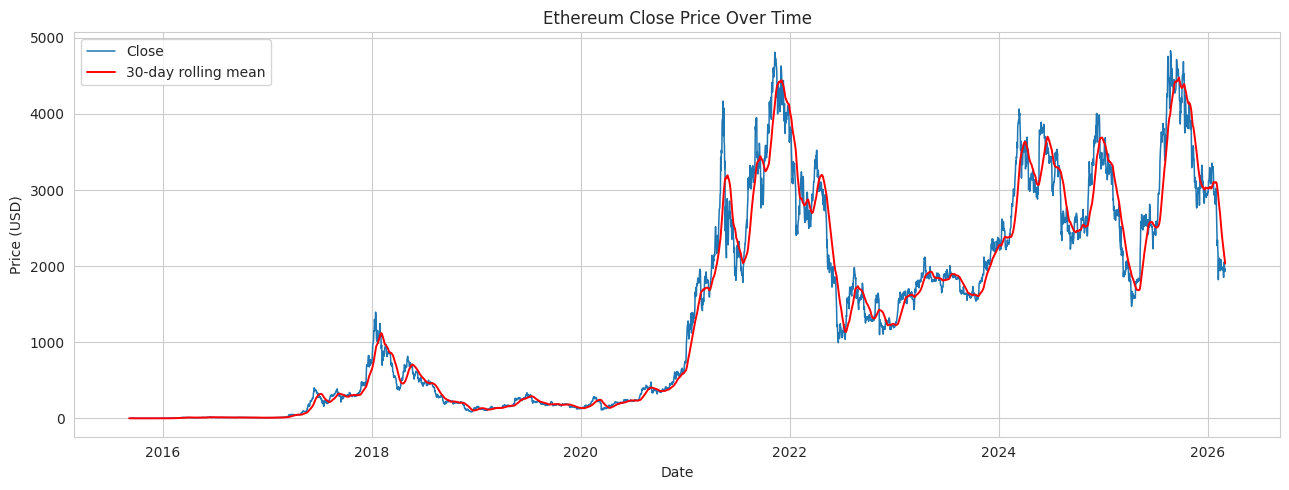

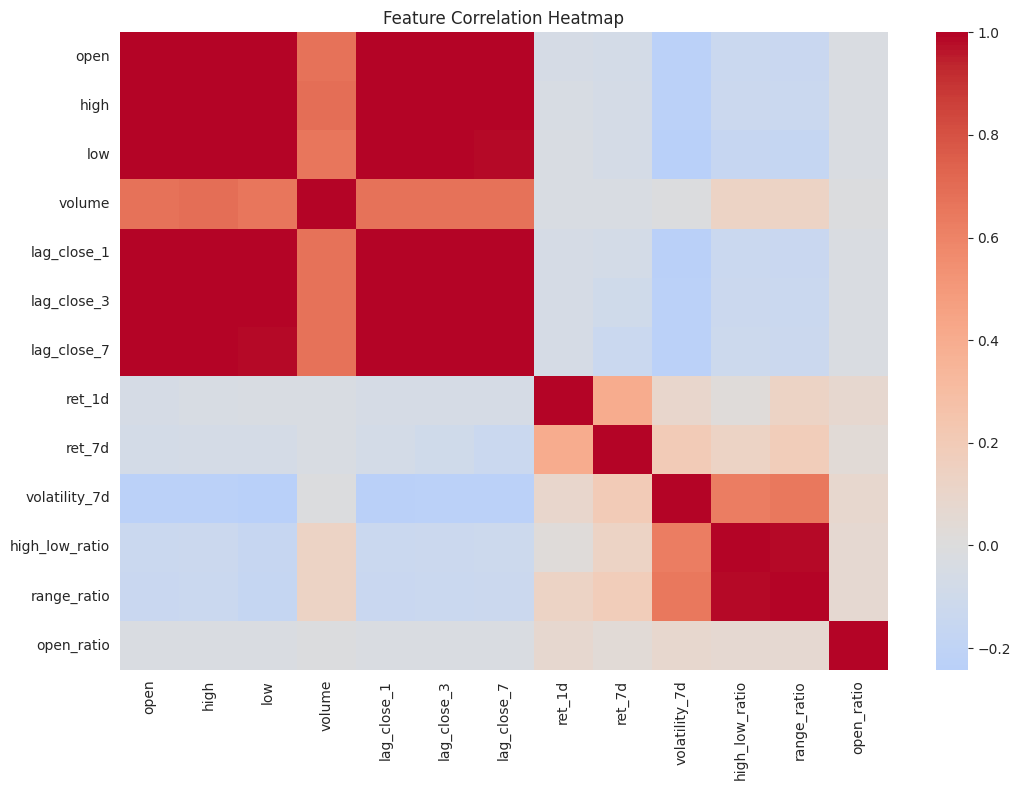

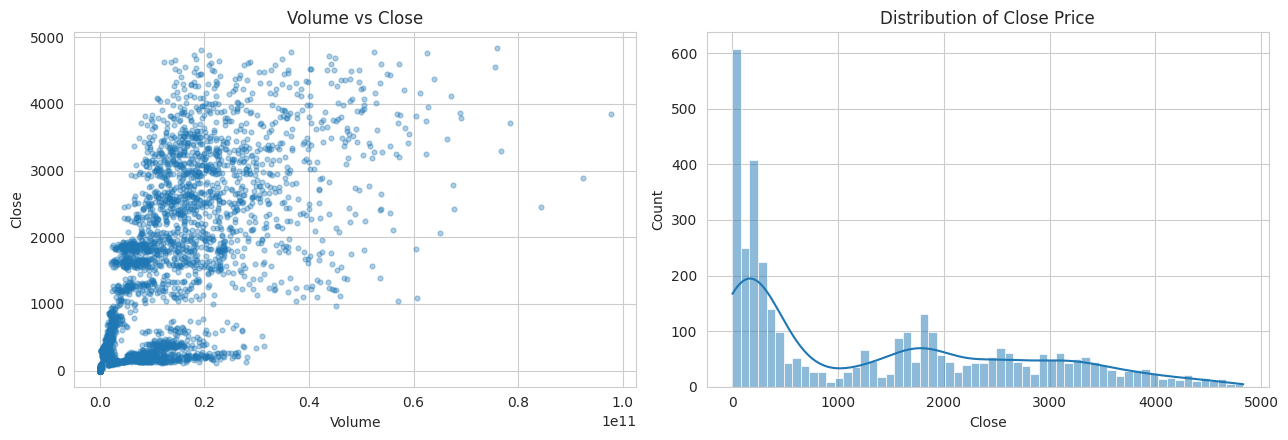

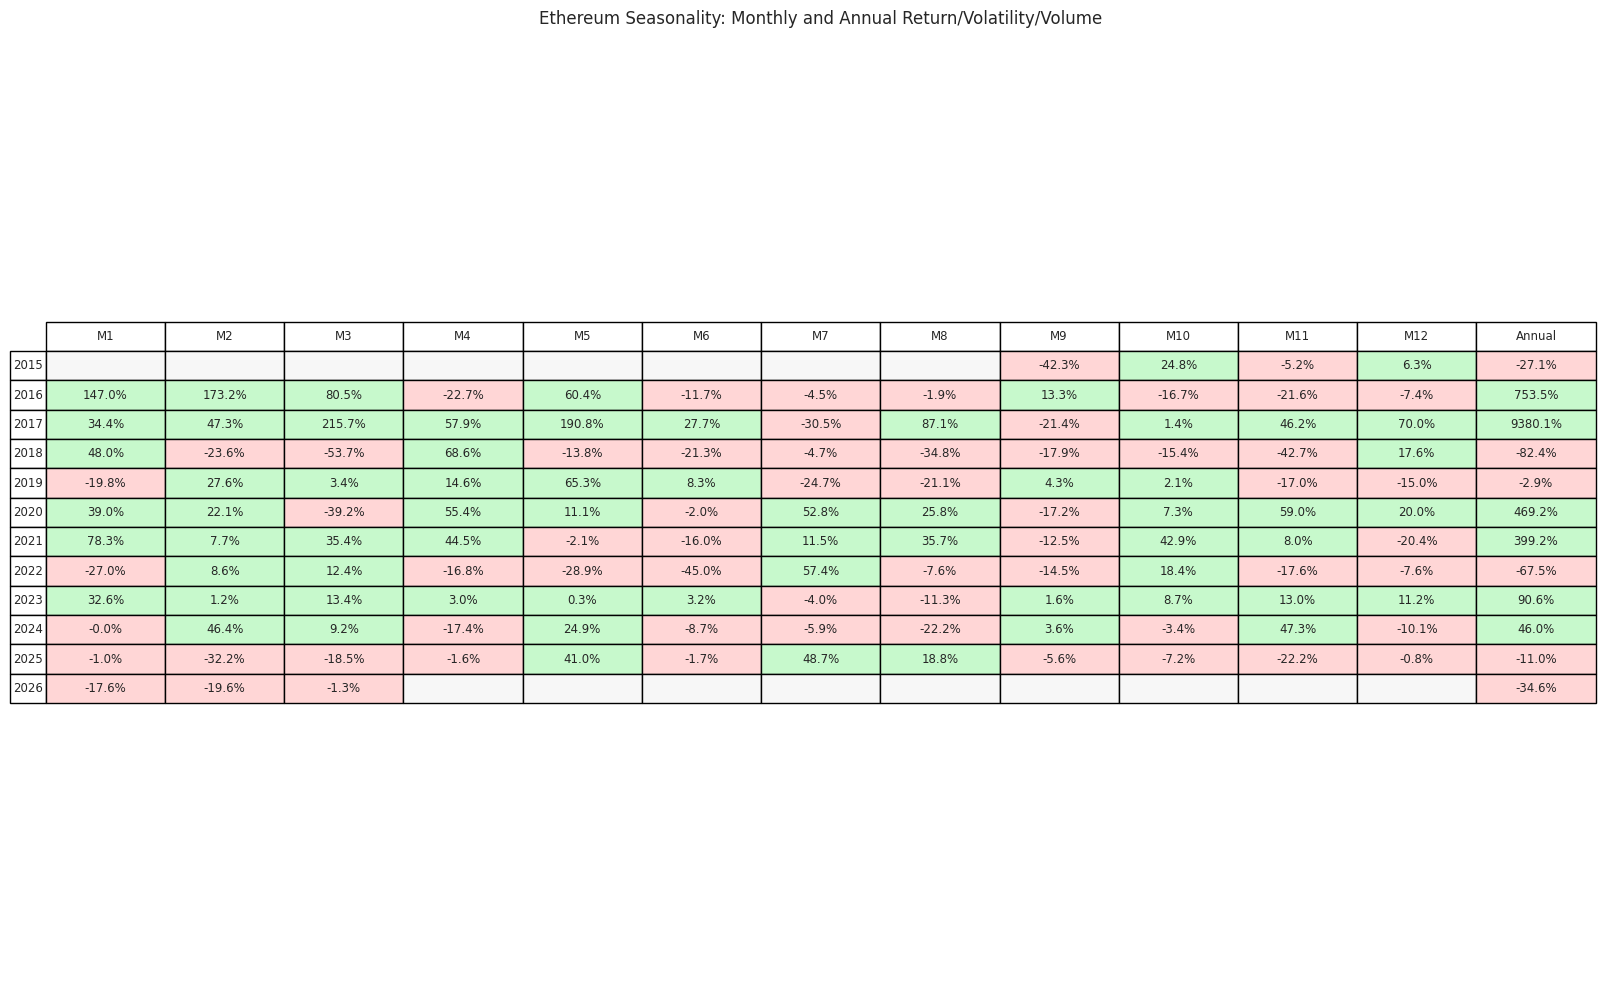

In [5]:
# Trend plot
plt.figure(figsize=(13, 5))
plt.plot(df_model.index, df_model["close"], label="Close", linewidth=1.1)
plt.plot(df_model.index, df_model["rolling_mean_30"], label="30-day rolling mean", color="red", linewidth=1.4)
plt.title("Ethereum Close Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(11, 8))
sns.heatmap(X_fe.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

# Scatter and histogram
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].scatter(df_model["volume"], df_model["close"], alpha=0.35, s=12)
axes[0].set_title("Volume vs Close")
axes[0].set_xlabel("Volume")
axes[0].set_ylabel("Close")

sns.histplot(df_model["close"], bins=60, kde=True, ax=axes[1])
axes[1].set_title("Distribution of Close Price")
axes[1].set_xlabel("Close")

plt.tight_layout()
plt.show()

# Seasonality table with return, volatility, average volume
tmp = df_model.copy()
tmp["year"] = tmp.index.year
tmp["month"] = tmp.index.month

monthly = tmp.groupby(["year", "month"]).agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_month=("close", "std"),
    avg_vol_month=("volume", "mean")
)
monthly["ret_month_pct"] = ((monthly["close_end"] - monthly["open_start"]) / monthly["open_start"]) * 100

annual = tmp.groupby("year").agg(
    open_start=("open", "first"),
    close_end=("close", "last"),
    vol_year=("close", "std"),
    avg_vol_year=("volume", "mean")
)
annual["ret_year_pct"] = ((annual["close_end"] - annual["open_start"]) / annual["open_start"]) * 100

seasonality_rows = sorted(tmp["year"].unique())
seasonality_cols = list(range(1, 13)) + [13]
col_labels = [f"M{m}" for m in range(1, 13)] + ["Annual"]

cell_text = []
cell_colors = []

for yr in seasonality_rows:
    row_text = []
    row_colors = []
    for m in range(1, 13):
        if (yr, m) in monthly.index:
            r = monthly.loc[(yr, m), "ret_month_pct"]
            row_text.append(f"{r:.1f}%")
            row_colors.append("#c7f9cc" if r > 0 else "#ffd6d6")
        else:
            row_text.append("")
            row_colors.append("#f7f7f7")

    r_a = annual.loc[yr, "ret_year_pct"]
    row_text.append(f"{r_a:.1f}%")
    row_colors.append("#c7f9cc" if r_a > 0 else "#ffd6d6")

    cell_text.append(row_text)
    cell_colors.append(row_colors)

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis("off")
tbl = ax.table(
    cellText=cell_text,
    rowLabels=seasonality_rows,
    colLabels=col_labels,
    cellColours=cell_colors,
    cellLoc="center",
    loc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)
tbl.scale(1.08, 1.45)
plt.title("Ethereum Seasonality: Monthly and Annual Return/Volatility/Volume", pad=15)
plt.tight_layout()
plt.show()

##### 5. Methodology and Algorithm Selection

Use chronological split and walk-forward CV to avoid look-ahead bias.

In [6]:
# Chronological split
split_idx = int(len(df_model) * 0.8)

X_bl_train, X_bl_test = X_bl.iloc[:split_idx], X_bl.iloc[split_idx:]
X_fe_train, X_fe_test = X_fe.iloc[:split_idx], X_fe.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print("Train size:", len(y_train), "Test size:", len(y_test))
print("Train class balance:\n", y_train.value_counts(normalize=True).rename("train_prop"))
print("Test class balance:\n", y_test.value_counts(normalize=True).rename("test_prop"))

tscv = TimeSeriesSplit(n_splits=5)

param_grid_dt = {
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "criterion": ["gini", "entropy"]
}

grid_dt_bl = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    cv=tscv,
    scoring="f1",
    n_jobs=-1
)
grid_dt_fe = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid=param_grid_dt,
    cv=tscv,
    scoring="f1",
    n_jobs=-1
)

grid_dt_bl.fit(X_bl_train, y_train)
grid_dt_fe.fit(X_fe_train, y_train)

print("Best DT params (baseline features):", grid_dt_bl.best_params_)
print("Best DT params (feature-engineered):", grid_dt_fe.best_params_)

Train size: 3064 Test size: 767
Train class balance:
 price_direction
1    0.504896
0    0.495104
Name: train_prop, dtype: float64
Test class balance:
 price_direction
1    0.509778
0    0.490222
Name: test_prop, dtype: float64
Best DT params (baseline features): {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 20}
Best DT params (feature-engineered): {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5, 'min_samples_split': 2}


##### 6. Implementation and Multi-Metric Evaluation

Evaluate baseline and feature-engineered variants using robust metrics.

In [7]:
def evaluate_classifier(model_name, model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = np.full(shape=len(y_test), fill_value=y_train.mean(), dtype=float)

    y_prob_clipped = np.clip(y_prob, 1e-6, 1 - 1e-6)

    metrics = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob),
        "PR_AUC": average_precision_score(y_test, y_prob),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "Kappa": cohen_kappa_score(y_test, y_pred),
        "Log_Loss": log_loss(y_test, y_prob_clipped),
        "Brier": brier_score_loss(y_test, y_prob)
    }
    return metrics, y_pred, y_prob, model

# Models
dummy_bl = DummyClassifier(strategy="most_frequent")
dt_bl = DecisionTreeClassifier(**grid_dt_bl.best_params_, random_state=RANDOM_STATE)
dt_fe = DecisionTreeClassifier(**grid_dt_fe.best_params_, random_state=RANDOM_STATE)

rf_bl = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5, min_samples_split=10,
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_fe = RandomForestClassifier(
    n_estimators=300, max_depth=10, min_samples_leaf=5, min_samples_split=10,
    random_state=RANDOM_STATE, n_jobs=-1
)

all_results = []
store = {}

for model_name, model_obj, Xtr, Xte in [
    ("Dummy_Baseline", dummy_bl, X_bl_train, X_bl_test),
    ("DT_Baseline", dt_bl, X_bl_train, X_bl_test),
    ("DT_FeatureEngineered", dt_fe, X_fe_train, X_fe_test),
    ("RF_Baseline", rf_bl, X_bl_train, X_bl_test),
    ("RF_FeatureEngineered", rf_fe, X_fe_train, X_fe_test),
]:
    m, y_pred, y_prob, fitted_model = evaluate_classifier(
        model_name, model_obj, Xtr, y_train, Xte, y_test
    )
    all_results.append(m)
    store[model_name] = {
        "y_pred": y_pred,
        "y_prob": y_prob,
        "model": fitted_model,
        "X_test": Xte
    }

results_df = pd.DataFrame(all_results).sort_values("F1", ascending=False).reset_index(drop=True)
display(results_df.round(4))

print("\nBest model by F1:")
print(results_df.loc[0, "Model"])

dummy_acc = results_df.loc[results_df["Model"] == "Dummy_Baseline", "Accuracy"].values[0]
best_acc = results_df.loc[0, "Accuracy"]
improve_abs = best_acc - dummy_acc
improve_pct = (improve_abs / dummy_acc) * 100 if dummy_acc != 0 else np.nan

print(f"\nBaseline (Dummy) Accuracy: {dummy_acc:.4f}")
print(f"Best Accuracy: {best_acc:.4f}")
print(f"Absolute Improvement: {improve_abs:.4f}")
print(f"Relative Improvement (%): {improve_pct:.2f}")

,Model,Accuracy,Balanced_Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC,MCC,Kappa,Log_Loss,Brier
0,Dummy_Baseline,0.5098,0.5000,0.5098,1.0000,0.6753,0.5000,0.5098,0.0000,0.0000,6.7727,0.4902
1,DT_FeatureEngineered,0.5267,0.5209,0.5229,0.8184,0.6381,0.5168,0.5200,0.0521,0.0423,0.8701,0.2568
2,DT_Baseline,0.5254,0.5253,0.5349,0.5294,0.5321,0.5275,0.5153,0.0507,0.0507,2.7790,0.3563
3,RF_Baseline,0.5033,0.5031,0.5128,0.5115,0.5122,0.5138,0.5165,0.0062,0.0062,0.7017,0.2540
4,RF_FeatureEngineered,0.5254,0.5262,0.5382,0.4859,0.5108,0.5284,0.5289,0.0526,0.0523,0.6966,0.2517



Best model by F1:
Dummy_Baseline

Baseline (Dummy) Accuracy: 0.5098
Best Accuracy: 0.5098
Absolute Improvement: 0.0000
Relative Improvement (%): 0.00


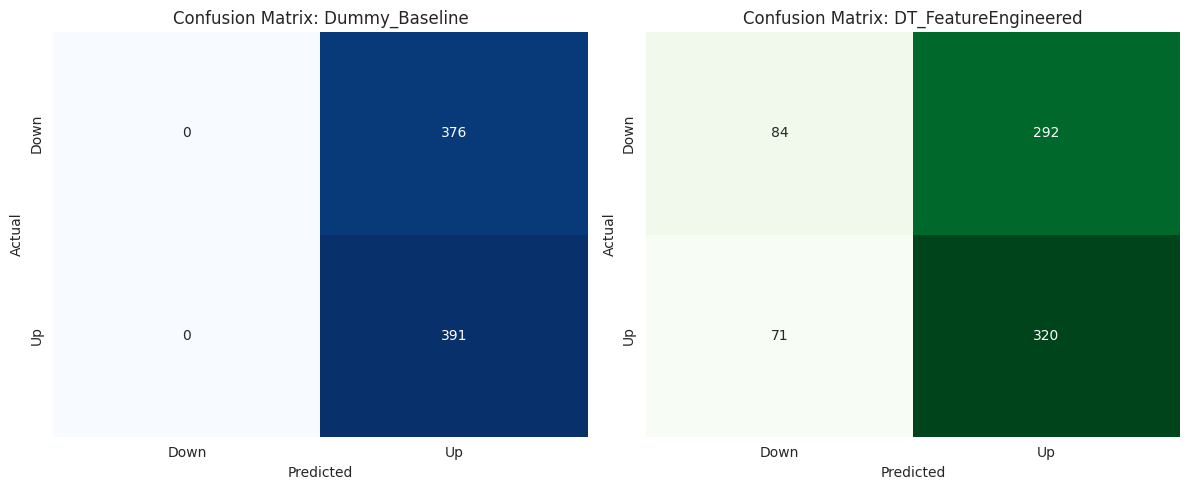

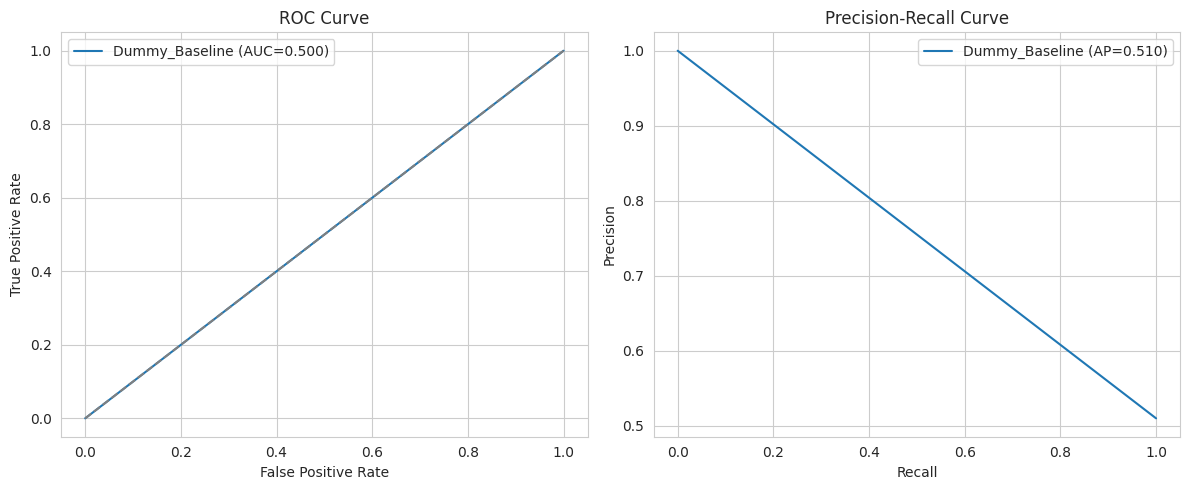


Classification report for best model:
              precision    recall  f1-score   support

        Down       0.00      0.00      0.00       376
          Up       0.51      1.00      0.68       391

    accuracy                           0.51       767
   macro avg       0.25      0.50      0.34       767
weighted avg       0.26      0.51      0.34       767



In [8]:
# Detailed diagnostics for top 2 models by F1
top_models = results_df["Model"].head(2).tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, model_name in enumerate(top_models):
    y_pred = store[model_name]["y_pred"]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cbar=False,
        xticklabels=["Down", "Up"], yticklabels=["Down", "Up"],
        cmap="Blues" if i == 0 else "Greens", ax=axes[i]
    )
    axes[i].set_title(f"Confusion Matrix: {model_name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC and PR curves for top model
best_model_name = results_df.loc[0, "Model"]
best_prob = store[best_model_name]["y_prob"]

fpr, tpr, _ = roc_curve(y_test, best_prob)
prec, rec, _ = precision_recall_curve(y_test, best_prob)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"{best_model_name} (AUC={roc_auc_score(y_test, best_prob):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC Curve")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

axes[1].plot(rec, prec, label=f"{best_model_name} (AP={average_precision_score(y_test, best_prob):.3f})")
axes[1].set_title("Precision-Recall Curve")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()

# Feature importance if model supports it
best_model_obj = store[best_model_name]["model"]
if hasattr(best_model_obj, "feature_importances_"):
    # Select matching feature names
    if "FeatureEngineered" in best_model_name:
        feat_names = X_fe_train.columns
    else:
        feat_names = X_bl_train.columns

    fi = pd.Series(best_model_obj.feature_importances_, index=feat_names).sort_values(ascending=False)
    plt.figure(figsize=(8, 5))
    fi.head(12).sort_values().plot(kind="barh", color="teal")
    plt.title(f"Top Feature Importances: {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

print("\nClassification report for best model:")
print(classification_report(y_test, store[best_model_name]["y_pred"], target_names=["Down", "Up"]))

##### 7. Evaluation and Comparison Summary

**Meaning of key metrics**
- **Accuracy**: overall correctness; can be misleading alone.
- **Balanced Accuracy**: average recall across classes; better for class imbalance.
- **Precision**: reliability of predicted positive class (Up).
- **Recall**: ability to capture actual positive class (Up).
- **F1**: balance of precision and recall.
- **ROC-AUC / PR-AUC**: ranking quality across thresholds.
- **MCC / Kappa**: robust agreement statistics beyond simple accuracy.
- **Log Loss / Brier**: probability calibration quality (lower is better).

**Critical comparison guidance**
- Compare **Dummy vs DT/RF** first to show non-trivial learning.
- Compare **Baseline vs Feature-Engineered** versions to quantify feature value.
- If one model has better recall but lower precision, discuss risk trade-offs.
- Cross-check numeric gains with confusion matrices and curve diagnostics.

In [9]:
output_path = Path("model_metrics_summary.csv")
results_df.to_csv(output_path, index=False)
print(f"Saved metrics table to: {output_path.resolve()}")

Saved metrics table to: /home/dev-algo/Documents/WLV-MSc-AI/01_Data_Mining_&_Informatics/W7_Final_Assessment/model_metrics_summary.csv
